$$ \renewcommand{\sech}{\operatorname{sech}} $$

The [Korteweg–De Vries equation or KdV-equation](https://en.wikipedia.org/wiki/Korteweg%E2%80%93De_Vries_equation) is a non-linear PDE that models 1-spatial-dimension dispersive non-dissipative soliton (solitary wave) which has the form
$$
    \frac{\partial u}{\partial t} + 6u\frac{\partial u}{\partial x} + \frac{\partial^3 u}{\partial x^3} = 0
$$
which on the space-time domain of $(x,t) \in [-2,2] \times [-2,2]$, if we impose the boundary and initial condition 
- $u(x,-2) = -2\sech^2(x+8)$ for $x \in [-2,2]$
- $u(-2,t) = -2\sech^2(-2-4t)$ for $t \in [-2,2]$
- $u(2,t) = -2\sech^2(2-4t)$ for $t \in [-2,2]$

then this leads to the closed-form solution
$$
    u(x,t) = -2\sech^2(x-4t)
$$

this notebook will primarily be on defining and training a PINN that can solve this KdV-equation and bechmark the predictions against the analytical solution above.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.dont_write_bytecode = True

%load_ext autoreload
from model import KdVPINN

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Backend set up for neural networks
torch.cuda.empty_cache()
# Set seed
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_default_dtype(torch.float32)

# CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
def sech(z):
    return 1.0 / torch.cosh(z)

def analytical_solution(x, t):
    return -2*sech(x-4*t)**2

In [13]:
"""
    PDE problem parameters
"""

# Domain
x_bounds = [-2,2]
t_bounds = [-2,2]

# Boundary and initial conditions
def boundary_left(t):
    return -2 * (sech(-2 - 4*t)**2)

def boundary_right(t):
    return -2 * (sech(2 - 4*t)**2)

def initial_condition(x):
    return -2 * (sech(x + 8)**2)

conditions = {
    "initial"        : initial_condition,
    "boundary_left"  : boundary_left,
    "boundary_right" : boundary_right
}

In [14]:
# Initialize solving PINN
%autoreload 2
pinn = KdVPINN(hidden_layers=[64,64,64,64,64]).to(device)

In [15]:
"""
    Training
"""
def train(pinn, x_bounds, t_bounds, conditions, model_path,
        epochs=5000, lr=0.001,
        collocation_points=2000, boundary_points=3000, initial_points=2000,
        print_interval=100):
    
    # Getting the domain
    x_min, x_max = x_bounds
    t_min, t_max = t_bounds

    # Setting up the optimizer
    optimizer = optim.Adam(pinn.model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=100, factor=0.5)

    # Data of best model
    smallest_mse = float("inf")
    best_epoch = 0

    # Loss history
    history = {
        "total_loss": [], 
        "residual_loss": [], 
        "boundary_loss": [],
        "initial_loss": [],
        "mse": []
    }

    #  Training loop
    pinn.model.train()

    # Training loop
    for epoch in range(epochs):

        # Zero out the gradient in optimizer
        optimizer.zero_grad()
        
        # Sample and compute loss on collocation points (interior domain)
        x_collocation = torch.rand(collocation_points, 1, device=device) * (x_max - x_min) + x_min
        t_collocation = torch.rand(collocation_points, 1, device=device) * (t_max - t_min) + t_min

        residual = pinn.kdv_residual(x_collocation, t_collocation)
        residual_loss = torch.mean(residual**2)

        # Initial condition (t = t_min)
        x_initial = torch.rand(initial_points, 1, device=device) * (x_max - x_min) + x_min
        t_initial = torch.ones_like(x_initial) * t_min
        pred_initial = pinn(x_initial, t_initial)
        true_initial = conditions["initial"](x_initial)
        initial_loss = torch.mean((pred_initial - true_initial)**2)
        
        # Left boundary (x = x_min)
        t_left = torch.rand(boundary_points, 1, device=device) * (t_max - t_min) + t_min
        x_left = torch.ones_like(t_left) * x_min
        pred_left = pinn(x_left, t_left)
        true_left = conditions["boundary_left"](t_left)
        loss_left = torch.mean((pred_left - true_left)**2)
        
        # Right boundary (x = x_max)
        t_right = torch.rand(boundary_points, 1, device=device) * (t_max - t_min) + t_min
        x_right = torch.ones_like(t_right) * x_max
        pred_right = pinn(x_right, t_right)
        true_right = conditions["boundary_right"](t_right)
        loss_right = torch.mean((pred_right - true_right)**2)

        # Loss and MSE calculation
        total_loss = 1.0 * residual_loss + 10.0 * loss_left + 10 * loss_right + 10.0 * initial_loss
        mse = residual_loss + loss_left + loss_right + initial_loss

        # Backpropagate and update
        total_loss.backward()
        
        # Gradient clipping to prevent instability
        torch.nn.utils.clip_grad_norm_(pinn.model.parameters(), max_norm=1.0)

        # Update optimizer and LR scheduler
        optimizer.step()
        scheduler.step(total_loss)

        # Store losses (for optional loss visualization)
        history["total_loss"].append(total_loss.item())
        history["residual_loss"].append(residual_loss.item())
        history["boundary_loss"].append((loss_left + loss_right).item())
        history["initial_loss"].append(initial_loss.item())
        history["mse"].append(mse.item())

        # Checkpoint the model states which has the lowest MSE
        if mse < smallest_mse:
            best_epoch = epoch
            smallest_mse = mse
            torch.save({
                "model": pinn.model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "losses": history,
                "best_epoch": best_epoch,
                "epoch": epoch,
                "x_bounds": x_bounds,
                "t_bounds": t_bounds
            }, model_path)

        # Print progress
        if epoch % print_interval == 0:
            print(f"Epoch {epoch:4d}: Total Loss = {total_loss.item():.6f} | "
                  f"Residual = {residual_loss.item():.6f} | "
                  f"Boundary = {(loss_left + loss_right).item():.6f} | "
                  f"Initial = {initial_loss.item():.6f} | "
                  f"MSE = {mse.item():.6f}")
            
    print(f"\nBest model occurred at epoch {best_epoch}, with lowest MSE of {smallest_mse:.6f}")
    print(f"Model saved to: {model_path}")

    return history

"""
    Loading checkpoint
"""
def load_model(model_path, device="cpu", silent=True):

    # Load the checkpoint
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)

    # Print some checkpoint data to console if we are not silent (a.k.a debugging)
    if not silent:
        print(f"Model loaded from epoch {checkpoint["epoch"]}")
        print(f"Best epoch: {checkpoint["best_epoch"]}")
    
    return checkpoint

In [16]:
model_path = "kdv_pinn_model.pth"

history = train(
    pinn=pinn, 
    x_bounds=x_bounds, 
    t_bounds=t_bounds,
    conditions=conditions,
    model_path=model_path,
    epochs=3001,
    lr=0.001,
    collocation_points=5000,
    boundary_points=3000,
    initial_points=3000,
    print_interval=300,
)

Epoch    0: Total Loss = 16.570564 | Residual = 0.452181 | Boundary = 1.442710 | Initial = 0.169128 | MSE = 2.064019
Epoch  300: Total Loss = 0.007599 | Residual = 0.001223 | Boundary = 0.000425 | Initial = 0.000212 | MSE = 0.001860
Epoch  600: Total Loss = 0.000252 | Residual = 0.000171 | Boundary = 0.000008 | Initial = 0.000000 | MSE = 0.000179
Epoch  900: Total Loss = 0.000170 | Residual = 0.000118 | Boundary = 0.000005 | Initial = 0.000000 | MSE = 0.000123
Epoch 1200: Total Loss = 0.000120 | Residual = 0.000082 | Boundary = 0.000004 | Initial = 0.000000 | MSE = 0.000086
Epoch 1500: Total Loss = 0.000094 | Residual = 0.000063 | Boundary = 0.000003 | Initial = 0.000000 | MSE = 0.000066
Epoch 1800: Total Loss = 0.000077 | Residual = 0.000056 | Boundary = 0.000002 | Initial = 0.000000 | MSE = 0.000058
Epoch 2100: Total Loss = 0.000066 | Residual = 0.000043 | Boundary = 0.000002 | Initial = 0.000000 | MSE = 0.000045
Epoch 2400: Total Loss = 0.000058 | Residual = 0.000042 | Boundary = 0.

In [17]:
def benchmark(pinn, model_path, analytical_solution, 
              x_bounds, t_bounds, 
              x_plot_pts=100, t_plot_pts=100):
    """
    Benchmark the trained model against analytical solution
    """
    # Load best model
    checkpoint = load_model(model_path, device=device)
    pinn.model.load_state_dict(checkpoint["model"])
    pinn.model.eval()
    
    # Setup domain
    x_min, x_max = x_bounds
    t_min, t_max = t_bounds
    
    # Create test grid
    x_test = torch.linspace(x_min, x_max, x_plot_pts, device=device)
    t_test = torch.linspace(t_min, t_max, t_plot_pts, device=device)
    X, T = torch.meshgrid(x_test, t_test, indexing="ij")
    X_flat = X.reshape(-1, 1)
    T_flat = T.reshape(-1, 1)
    
    # Predictions
    with torch.no_grad():
        u_pred = pinn.predict(X_flat, T_flat).reshape(x_plot_pts, t_plot_pts).cpu().numpy()
        u_analytical = analytical_solution(X, T).cpu().numpy()
    
    # Calculate error
    error = np.abs(u_pred - u_analytical)
    
    # Convert to numpy for plotting
    X_np = X.cpu().numpy()
    T_np = T.cpu().numpy()
    
    # Performance visualization
    fig = plt.figure(figsize=(16, 12))
    
    # 1. PINN Prediction
    ax1 = fig.add_subplot(2, 2, 1, projection="3d")
    surf1 = ax1.plot_surface(X_np, T_np, u_pred, cmap="viridis")
    ax1.set_xlabel("x")
    ax1.set_ylabel("t")
    ax1.set_zlabel("u(x,t)")
    ax1.set_title("PINN Prediction")
    fig.colorbar(surf1, ax=ax1, shrink=0.5)
    
    # 2. Analytical Solution
    ax2 = fig.add_subplot(2, 2, 2, projection="3d")
    surf2 = ax2.plot_surface(X_np, T_np, u_analytical, cmap="viridis")
    ax2.set_xlabel("x")
    ax2.set_ylabel("t")
    ax2.set_zlabel("u(x,t)")
    ax2.set_title("Analytical Solution")
    fig.colorbar(surf2, ax=ax2, shrink=0.5)
    
    # 3. Absolute Error Heatmap
    ax3 = fig.add_subplot(2, 2, 3)
    im1 = ax3.contourf(X_np, T_np, error, levels=50, cmap="hot")
    ax3.set_xlabel("x")
    ax3.set_ylabel("t")
    ax3.set_title(f"Absolute Error\nMax: {np.max(error):.3e}, Mean: {np.mean(error):.3e}")
    ax3.set_aspect('equal')
    fig.colorbar(im1, ax=ax3)
    
    # 4. Cross-sections comparisons
    ax4 = fig.add_subplot(2, 2, 4)
    t_indices = [0, t_plot_pts//4, t_plot_pts//2, 3*t_plot_pts//4, -1]
    colors = ["red", "blue", "green", "orange", "purple"]
    t_vals = t_test.cpu().numpy()
    
    for i, idx in enumerate(t_indices):
        t_val = t_vals[idx]
        ax4.plot(X_np[:, idx], u_pred[:, idx], 
                color=colors[i], linestyle="-", linewidth=2, 
                label=f"PINN t={t_val:.2f}")
        ax4.plot(X_np[:, idx], u_analytical[:, idx], 
                color=colors[i], linestyle="--", alpha=0.7, 
                label=f"Analytical t={t_val:.2f}")
    
    ax4.set_xlabel("x")
    ax4.set_ylabel("u(x,t)")
    ax4.set_title("Cross-sections at different times")
    ax4.legend(fontsize=8)
    ax4.grid(True)
    
    plt.tight_layout()
    plt.savefig("kdv_pinn_benchmark.png", dpi=450, bbox_inches='tight')
    plt.show()



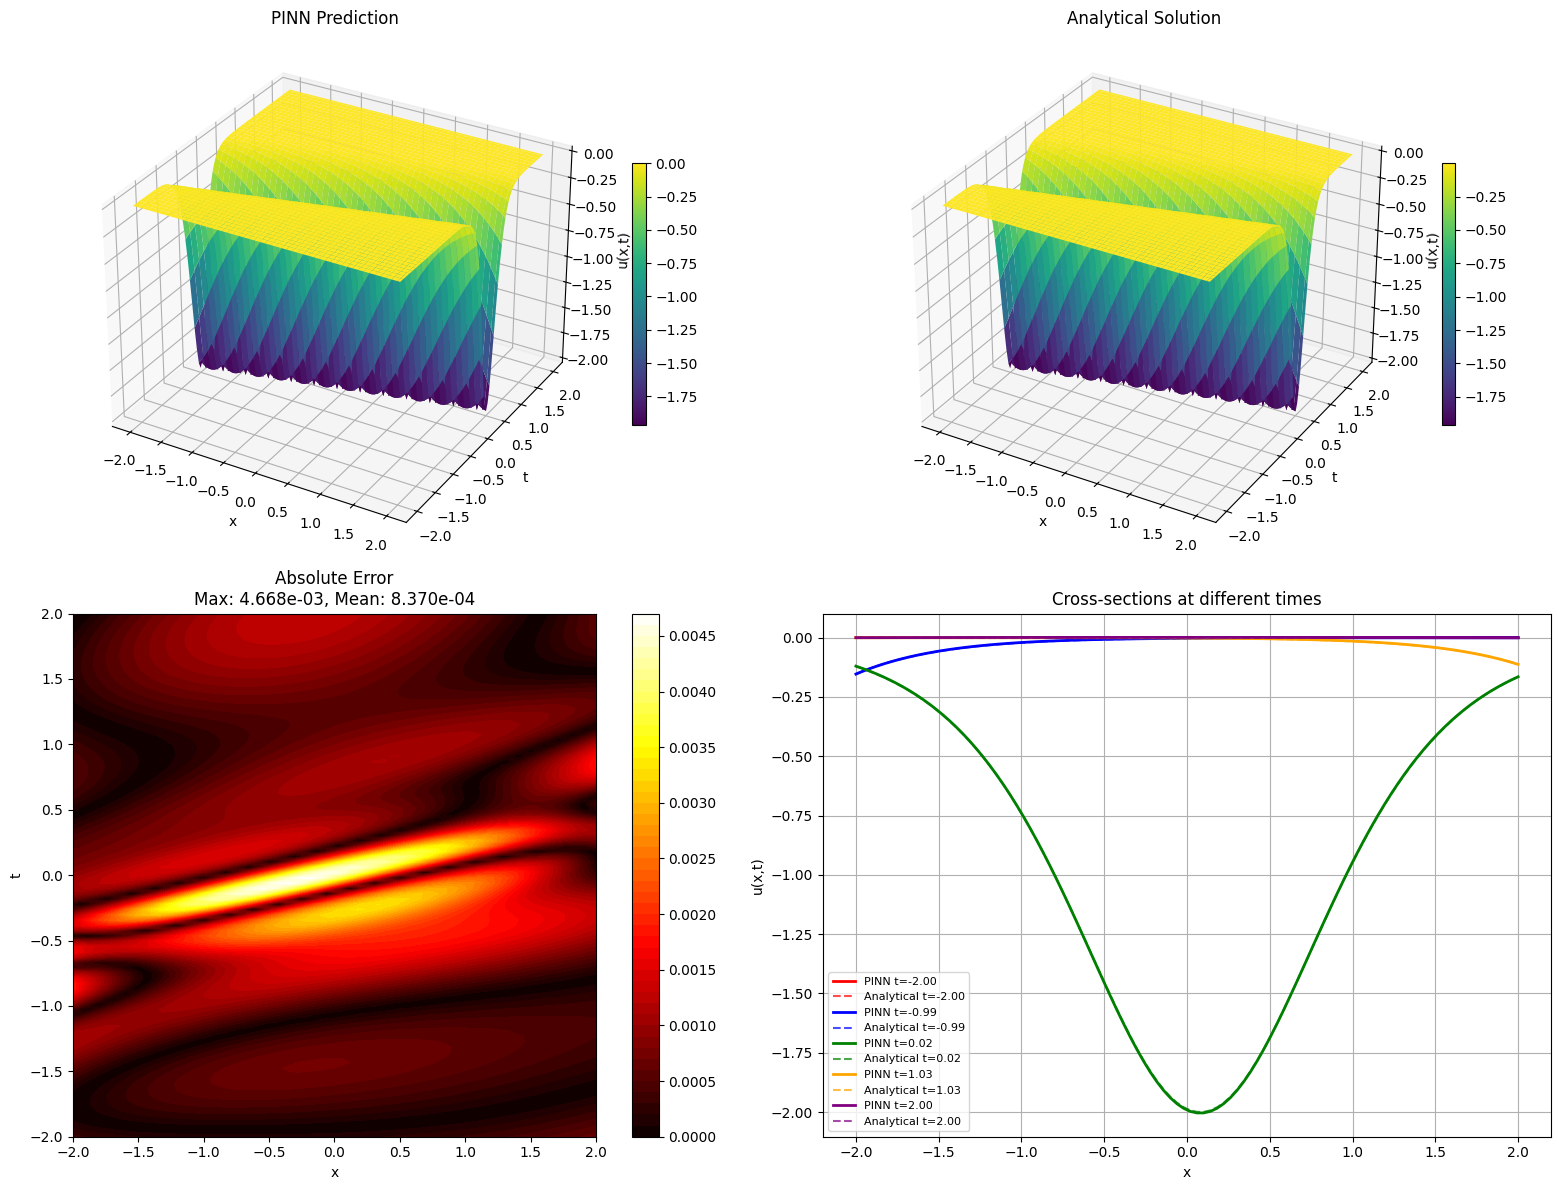

In [18]:
benchmark(pinn=pinn,
        analytical_solution=analytical_solution,
        x_bounds=x_bounds, t_bounds=t_bounds,
        model_path=model_path)